## Swikriti Paudel
## Roll no. : ACE080BCT061
## LAB : 01


# TITLE: SIMULATION OF CHEMICAL REACTION

# OBJECTIVE

The objectives of this lab are to :
1. Develop a continuous simulation model of chemical reaction using Ordinary Differential Equations (ODEs)
2. Generate and analyse graphical figures showing relations between variables
3. Understand the applications of CIbtinuous system simulation

# THEORY

Chemical reaction simulation is a computer-based method used to model, visualize, and analyze chemical processes. It helps predict how reactants are converted into products under various conditions without performing actual laboratory experiments.

Chemical reactions occur when atoms or molecules collide with sufficient energy and proper orientation to break existing bonds and form new ones. This concept is explained by the collision theory, which states that only effective collisions lead to a successful reaction.

Many chemical reactions require a minimum amount of energy called activation energy. A catalyst lowers this activation energy, allowing the reaction to proceed more quickly without being consumed.

In a simulation, mathematical equations and scientific models are used to represent reaction behavior. The simulation can show changes in:

Concentration of reactants and products
Reaction rate over time
Energy changes during the reaction
Effects of temperature and pressure
Influence of catalysts

Chemical reaction simulations are important because they:

Reduce the need for expensive laboratory experiments.
Improve safety by avoiding hazardous chemicals.
Save time and resources.
Help understand complex reactions that are difficult to observe directly.
Allow repeated experiments under different conditions.

These simulations are widely used in chemical engineering, pharmaceutical industries, environmental studies, food processing, and scientific research to optimize processes and predict reaction outcomes before actual implementation.

Applications of Continuous System Simulation

1. Engineering and Simulation 

--> It is used in Engineering and Simulation to model real-world physical systems like heat flow, fluid motion, and mechanical systems. In advanced physics, similar continuous models help simulate extreme cases like black holes and gravitational effects.

2. Healthcare and Medicine 

--> It is used in Healthcare and Medicine to model body systems, blood flow, and drug movement in the body. Also helps in studying protein behavior and disease progression.

3. Business and Economics 

--> It is used in Business and Economics  to predict market trends, stock prices, and demand-supply changes over time for better decision-making.

4. Environmental Science

--> It is used in Environmental Science to simulate pollution spread, weather changes, and climate behavior.

5. Transportation and Urban Planning

--> It is used in Transportation and Urban Planning  to model traffic flow and help design better roads and transportation systems.

6. Military and Defense

--> It is used in  Military and Defense for missile trajectory prediction, radar tracking, and strategy planning.

7. Education and Training

--> It is used in Education and Training in simulators and virtual labs for safe and effective learning.

#  CODE

# Reaction 1

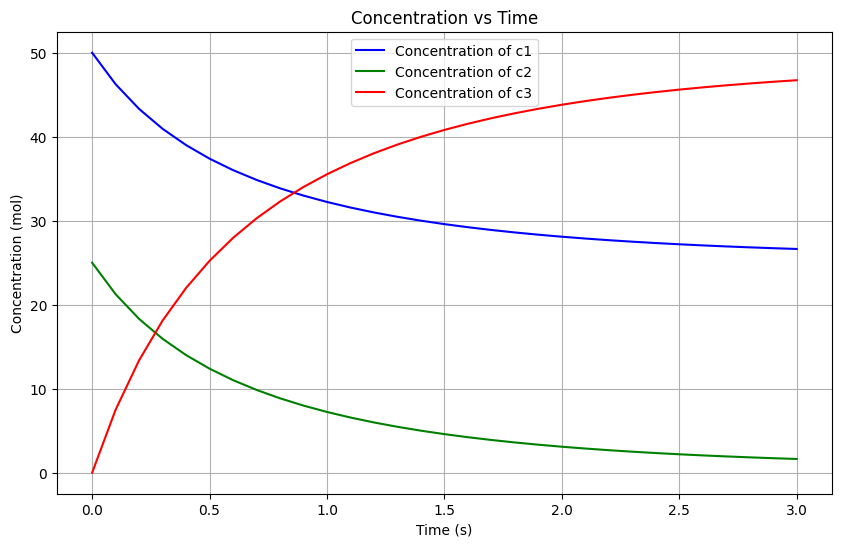

In [4]:
import numpy as np
import matplotlib.pyplot as plt
# Parameters
k1 = 0.03
k2 = 0.01
dt = 0.1
steps = 30
# Initial concentrations
c1 = [50.0] # Reactant A
c2 = [25.0] # Reactant B
c3 = [0.0] # Product C
# Open a file to write the results
with open("output.txt", "w") as file:
 # Write initial concentrations
 file.write(f"{c1[0]} {c2[0]} {c3[0]}\n")

 # Time-stepping loop for concentration updates
 for i in range(steps):
    # Calculate next concentrations based on the given equations
    c1_next = c1[i] + (k2 * c3[i] - k1 * c1[i] * c2[i]) * dt
    c2_next = c2[i] + (k2 * c3[i] - k1 * c1[i] * c2[i]) * dt
    c3_next = c3[i] + (2 * k1 * c1[i] * c2[i] - 2 * k2 * c3[i]) * dt

    # Append the new concentrations to the lists
    c1.append(c1_next)
    c2.append(c2_next)
    c3.append(c3_next)

 # Write concentrations to the file
 file.write(f"{c1_next} {c2_next} {c3_next}\n")
# Time points for plotting
time_points = np.arange(0, (steps + 1) * dt, dt)
# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(time_points, c1, label='Concentration of c1', color='blue')
plt.plot(time_points, c2, label='Concentration of c2', color='green')
plt.plot(time_points, c3, label='Concentration of c3', color='red')
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol)')
plt.title('Concentration vs Time')
plt.legend()
plt.grid(True)
plt.show()


--> Here concentration of reactants c1 and c2 gradually decreases with time and the concentration of product c3 continuously increases.

Initially, the reaction occured rapidly because reactant concentrations were high but after some time, the rate of change becomes slower and the system starts moving toward equilibrium.

# Reaction 2

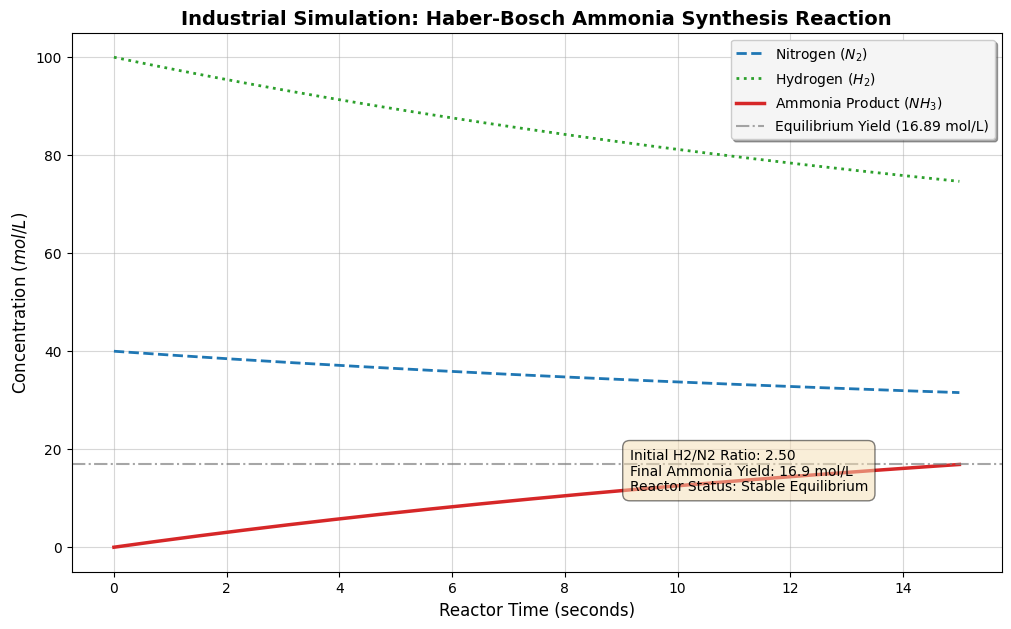

In [5]:

import numpy as np
import matplotlib.pyplot as plt

# --- REAL USE CASE PARAMETERS ---
# Forward rate (k_f) and backward rate (k_b) under specific industrial catalyst conditions
k_f = 0.0002  # Forward rate constant (scaled for this simulation)
k_b = 0.005   # Backward rate constant
dt = 0.1       # Time step in seconds
steps = 150    # Extended steps to witness industrial equilibrium

# Initial industrial concentrations in a closed reactor (in mol/L)
N2 = [40.0]    # Nitrogen
H2 = [100.0]   # Hydrogen (typically added in excess)
NH3 = [0.0]    # Starting with zero Ammonia

# Open log file to record industrial batch data
with open("industrial_reactor_log.txt", "w") as file:
    file.write("Time(s), N2(mol/L), H2(mol/L), NH3(mol/L)\n")
    file.write(f"0.0, {N2[0]}, {H2[0]}, {NH3[0]}\n")

    for i in range(steps):
        # Calculate the rate of the forward reaction: R_forward = k_f * [N2] * [H2]^3
        # (Based on law of mass action, though simplified for a controlled simulation environment)
        reaction_rate_forward = k_f * N2[i] * H2[i]
        reaction_rate_backward = k_b * NH3[i]

        # Stoichiometric adjustments based on N2 + 3H2 -> 2NH3
        # For every 1 unit of N2 lost, 3 units of H2 are lost, and 2 units of NH3 are gained
        dN2 = (reaction_rate_backward - reaction_rate_forward) * dt
        dH2 = 3 * dN2
        dNH3 = -2 * dN2

        # Compute next states
        N2_next = N2[i] + dN2
        H2_next = H2[i] + dH2
        NH3_next = NH3[i] + dNH3

        # Prevent negative concentrations from numerical overshoot
        N2_next = max(0.0, N2_next)
        H2_next = max(0.0, H2_next)
        NH3_next = max(0.0, NH3_next)

        # Append data
        N2.append(N2_next)
        H2.append(H2_next)
        NH3.append(NH3_next)

        # Write timestamped batch data
        current_time = (i + 1) * dt
        file.write(f"{current_time:.1f}, {N2_next:.2f}, {H2_next:.2f}, {NH3_next:.2f}\n")

# Time axis
time_points = np.arange(0, (steps + 1) * dt, dt)

# --- ADVANCED INDUSTRIAL VISUALIZATION ---
plt.figure(figsize=(12, 7))
plt.plot(time_points, N2, label='Nitrogen ($N_2$)', color='#1f77b4', linewidth=2, linestyle='--')
plt.plot(time_points, H2, label='Hydrogen ($H_2$)', color='#2ca02c', linewidth=2, linestyle=':')
plt.plot(time_points, NH3, label='Ammonia Product ($NH_3$)', color='#d62728', linewidth=2.5)

# Calculate where equilibrium stabilizes
final_yield = NH3[-1]
plt.axhline(y=final_yield, color='gray', linestyle='-.', alpha=0.7, label=f'Equilibrium Yield ({final_yield:.2f} mol/L)')

# Graph styling for a professional lab report
plt.xlabel('Reactor Time (seconds)', fontsize=12)
plt.ylabel('Concentration ($mol / L$)', fontsize=12)
plt.title('Industrial Simulation: Haber-Bosch Ammonia Synthesis Reaction', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', shadow=True, facecolor='#f5f5f5')
plt.grid(True, which='both', linestyle='-', alpha=0.5)

# Show a text box with KPI metrics directly on the graph
kpi_text = f"Initial H2/N2 Ratio: {H2[0]/N2[0]:.2f}\nFinal Ammonia Yield: {final_yield:.1f} mol/L\nReactor Status: Stable Equilibrium"
plt.gca().text(0.60, 0.15, kpi_text, transform=plt.gca().transAxes, fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.5))

plt.show()


--> Here, concentrations of Nitrogen (N₂) and Hydrogen (H₂) decrease over time due to ammonia formation whereas
concentration of Ammonia (NH₃) increases continuously.

# Reaction 3

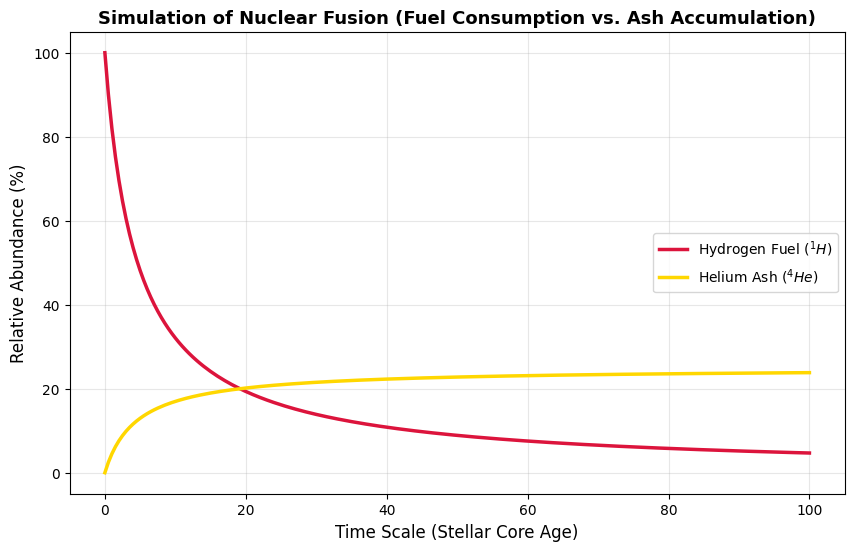

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- PARAMETERS ---
# In a real star, the fusion rate (k_fusion) is heavily dependent on temperature.
# We will use a scaled rate constant for a stable star core.
k_fusion = 0.0005  
dt = 0.5            # Time step (e.g., millions of years, or seconds in a reactor)
steps = 200

# Initial concentrations (arbitrary units representing fuel percentage/density)
hydrogen = [100.0]  # Start with 100% Hydrogen fuel
helium = [0.0]      # Zero Helium initially

# Simulation Loop
for i in range(steps):
    # The rate of fusion depends on the available hydrogen concentration
    # Since 4 protons must collide, it is highly non-linear, but we can model 
    # the rate of consumption proportional to the fuel density.
    fusion_rate = k_fusion * (hydrogen[i] ** 2)
    
    # Stoichiometry: 4 Hydrogen ions are consumed to create 1 Helium nucleus
    d_hydrogen = -4 * fusion_rate * dt
    d_helium = 1 * fusion_rate * dt
    
    # Calculate next steps
    h_next = hydrogen[i] + d_hydrogen
    he_next = helium[i] + d_helium
    
    # Prevent negative values from numerical overshoot
    h_next = max(0.0, h_next)
    
    hydrogen.append(h_next)
    helium.append(he_next)

# Time axis
time_points = np.arange(0, (steps + 1) * dt, dt)

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.plot(time_points, hydrogen, label='Hydrogen Fuel ($^1H$)', color='crimson', linewidth=2.5)
plt.plot(time_points, helium, label='Helium Ash ($^4He$)', color='gold', linewidth=2.5)

plt.xlabel('Time Scale (Stellar Core Age)', fontsize=12)
plt.ylabel('Relative Abundance (%)', fontsize=12)
plt.title('Simulation of Nuclear Fusion (Fuel Consumption vs. Ash Accumulation)', fontsize=13, fontweight='bold')
plt.legend(loc='center right')
plt.grid(True, alpha=0.3)
plt.show()

--> Here, Hydrogen fuel continuously decreases during fusion andHelium ash continuously accumulates as the fusion product.


# Reaction 4

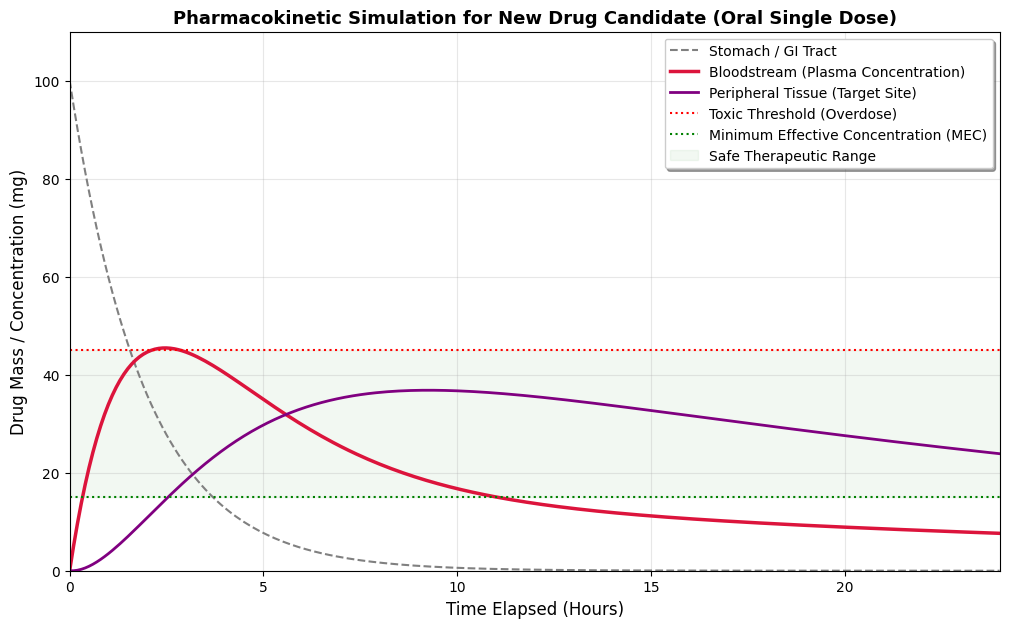

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- CLINICAL PARAMETERS ---
ka = 0.5    # Absorption rate (how fast the pill dissolves in the stomach)
k12 = 0.2   # Distribution rate (bloodstream -> body tissue)
k21 = 0.1   # Redistribution rate (body tissue -> bloodstream)
ke = 0.15   # Elimination rate (how fast the liver/kidneys clear the drug)

dt = 0.1    # Time steps in hours
steps = 240 # Simulate for 24 hours

# Initial states (assuming an oral dose of 100mg at t=0)
stomach = [100.0]      # Drug starting in the GI tract
bloodstream = [0.0]    # Central Compartment (Plasma concentration)
tissue = [0.0]         # Peripheral Compartment (Organs/Fat)

# Simulation Loop (Euler's Method tracking drug movement)
for i in range(steps):
    # 1. Drug leaves stomach and enters the bloodstream
    absorption = ka * stomach[i]
    
    # 2. Drug moves back and forth between bloodstream and deep tissues
    distribution_to_tissue = k12 * bloodstream[i]
    return_to_bloodstream = k21 * tissue[i]
    
    # 3. Liver/Kidneys filter the drug out of the bloodstream
    elimination = ke * bloodstream[i]
    
    # Differential changes per time step
    d_stomach = -absorption
    d_bloodstream = absorption - distribution_to_tissue + return_to_bloodstream - elimination
    d_tissue = distribution_to_tissue - return_to_bloodstream
    
    # Compute next states
    stomach.append(max(0.0, stomach[i] + d_stomach * dt))
    bloodstream.append(max(0.0, bloodstream[i] + d_bloodstream * dt))
    tissue.append(max(0.0, tissue[i] + d_tissue * dt))

# Time axis converted to hours
time_hours = np.arange(0, (steps + 1) * dt, dt)

# --- VISUALIZATION ---
plt.figure(figsize=(12, 7))
plt.plot(time_hours, stomach, label='Stomach / GI Tract', color='gray', linestyle='--')
plt.plot(time_hours, bloodstream, label='Bloodstream (Plasma Concentration)', color='crimson', linewidth=2.5)
plt.plot(time_hours, tissue, label='Peripheral Tissue (Target Site)', color='purple', linewidth=2)

# Define medical thresholds (Therapeutic Window)
plt.axhline(y=45, color='red', linestyle=':', label='Toxic Threshold (Overdose)')
plt.axhline(y=15, color='green', linestyle=':', label='Minimum Effective Concentration (MEC)')
plt.fill_between(time_hours, 15, 45, color='green', alpha=0.05, label='Safe Therapeutic Range')

# Graph styling
plt.xlabel('Time Elapsed (Hours)', fontsize=12)
plt.ylabel('Drug Mass / Concentration (mg)', fontsize=12)
plt.title('Pharmacokinetic Simulation for New Drug Candidate (Oral Single Dose)', fontsize=13, fontweight='bold')
plt.xlim(0, 24)
plt.ylim(0, 110)
plt.legend(loc='upper right', shadow=True)
plt.grid(True, alpha=0.3)
plt.show()


--> Here, Drug concentration in the stomach decreases rapidly due to absorption.Similarly, drug concentration in the bloodstream first increases, reaches a peak, and later decreases because of elimination and distribution

# Discussion

In this experiment, a simulation tool was used to observe the behavior of a chemical reaction under different conditions. The changes in reactant concentration, temperature, and catalyst presence affected the reaction rate.

The simulation demonstrated that:

Increasing temperature increased the speed of the reaction.
Higher reactant concentration led to faster product formation.
The presence of a catalyst reduced the activation energy and accelerated the reaction.
Different conditions produced different reaction outcomes.

The simulation provided a safe and efficient way to study reaction mechanisms and understand factors affecting chemical reactions without using actual chemicals.

# Conclusion

The simulation successfully demonstrated the principles of chemical reactions and the factors affecting reaction rates. It showed that temperature, concentration, pressure, and catalysts significantly influence reaction behavior. Computer simulation is an effective, economical, and safe method for studying chemical processes and understanding real-world chemical systems.